In [23]:
import torch

In [24]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current Device: {device}")
#"cuda" - PyTorch can see the GPU

Current Device: cuda


In [25]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
M = M.to(device)
M.device

device(type='cuda', index=0)

In [26]:
#imports and other setup code (including setting up device)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"Device: {device}")

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def print_metrics(name, y_true, y_pred):
    print(f"{'Model':<30} {'RMSE':>10} {'MAE':>10} {'MAPE':>10}")
    print("-" * 62)
    print(f"{name:<30} {rmse(y_true, y_pred):>10.4f} {mae(y_true, y_pred):>10.4f} {mape(y_true, y_pred):>9.2f}%")

Device: cuda


# Problem 1

## Data preparation

In [27]:
Data = pd.read_csv("energydata_complete.csv")
Data['date'] = pd.to_datetime(Data['date'])
# Add time-based features as required by the assignment
Data['day_of_week'] = Data['date'].dt.dayofweek  # 0=Monday, 6=Sunday
Data['hour']        = Data['date'].dt.hour
print(f"Dataset shape: {Data.shape}")
print(f"Date range:    {Data['date'].min()} to {Data['date'].max()}")
print(f"Appliances:    min={Data['Appliances'].min()} Wh, "
      f"max={Data['Appliances'].max()} Wh, mean={Data['Appliances'].mean():.1f} Wh")

Dataset shape: (19735, 31)
Date range:    2016-01-11 17:00:00 to 2016-05-27 18:00:00
Appliances:    min=10 Wh, max=1080 Wh, mean=97.7 Wh


date time year-month-day hour:minute:second  
Appliances, energy use in Wh 
lights, energy use of light fixtures in the house in Wh  
T1, Temperature in kitchen area, in Celsius  
RH_1, Humidity in kitchen area, in %  
T2, Temperature in living room area, in Celsius  
RH_2, Humidity in living room area, in %  
T3, Temperature in laundry room area  
RH_3, Humidity in laundry room area, in %  
T4, Temperature in office room, in Celsius  
RH_4, Humidity in office room, in %  
T5, Temperature in bathroom, in Celsius  
RH_5, Humidity in bathroom, in %  
T6, Temperature outside the building (north side), in Celsius  
RH_6, Humidity outside the building (north side), in %  
T7, Temperature in ironing room , in Celsius  
RH_7, Humidity in ironing room, in %  
T8, Temperature in teenager room 2, in Celsius  
RH_8, Humidity in teenager room 2, in %  
T9, Temperature in parents room, in Celsius  
RH_9, Humidity in parents room, in %  
To, Temperature outside (from Chievres weather station), in Celsius  
Pressure (from Chievres weather station), in mm Hg  
RH_out, Humidity outside (from Chievres weather station), in %  
Wind speed (from Chievres weather station), in m/s  
Visibility (from Chievres weather station), in km  
Tdewpoint (from Chievres weather station), Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â°C  
rv1, Random variable 1, nondimensional  
rv2, Random variable 2, nondimensional  

In [28]:
Data.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,day_of_week,hour
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,0,17
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,0,17
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,0,17
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,0,17
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,0,17


In [29]:
#train, validation, and test sets
train_size = int(0.7 * len(Data))
val_size = int(0.15 * len(Data))
test_size = len(Data) - train_size - val_size
train_data = Data[:train_size]
val_data = Data[train_size:train_size + val_size]
test_data = Data[train_size + val_size:]
print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

Train size: 13814
Validation size: 2960
Test size: 2961


In [30]:
from sklearn.preprocessing import MinMaxScaler

# Put Appliances first so SeqDataset(target_idx=0) targets it correctly
feature_cols = ['Appliances'] + [
    col for col in Data.columns
    if col not in ('Appliances', 'date')
]
INPUT_SIZE = len(feature_cols)
print(f"Input features ({INPUT_SIZE}): {feature_cols}")

scaler = MinMaxScaler()
scaler.fit(train_data[feature_cols])
train_scaled = scaler.transform(train_data[feature_cols])
val_scaled   = scaler.transform(val_data[feature_cols])
test_scaled  = scaler.transform(test_data[feature_cols])

# Min/max of the target (Appliances at idx 0) for inverse transform
target_min = scaler.data_min_[0]
target_max = scaler.data_max_[0]
print(f"Appliances training range: [{target_min:.1f}, {target_max:.1f}] Wh")

Input features (30): ['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'day_of_week', 'hour']
Appliances training range: [10.0, 1080.0] Wh


In [31]:
class SeqDataset(Dataset):
    def __init__(self, data, seq_len, horizon, target_idx=0): #target_idx, self.tidx - index of column where the target (energy) is stored
        self.data, self.seq_len = torch.FloatTensor(data), seq_len
        self.horizon, self.tidx = horizon, target_idx
    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1
    def __getitem__(self, i):
        x = self.data[i : i+self.seq_len]
        y = self.data[i+self.seq_len+self.horizon-1, self.tidx]
        return x, y

In [32]:
class SeqToSeqDataset(Dataset):
    """Returns (input_sequence, horizon_targets) pairs for seq-to-seq training."""
    def __init__(self, data, seq_len, horizon, target_idx=0):
        self.data = torch.FloatTensor(data)
        self.seq_len, self.horizon, self.tidx = seq_len, horizon, target_idx
    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1
    def __getitem__(self, i):
        x = self.data[i : i + self.seq_len]
        y = self.data[i + self.seq_len : i + self.seq_len + self.horizon, self.tidx]
        return x, y

In [33]:
class LSTMModel(nn.Module):
    """Sequence-to-one LSTM: reads a window, outputs a single scalar."""
    def __init__(self, input_size=None, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        if input_size is None:
            input_size = INPUT_SIZE
        self.lstm = nn.LSTM(input_size, hidden, layers,
                            dropout=dropout if layers > 1 else 0,
                            batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1)
        )

    def forward(self, x):
        _, (h, _) = self.lstm(x)         # h: (layers, batch, hidden)
        return self.head(h[-1]).squeeze(-1)  # (batch,)

In [34]:
class Seq2SeqLSTM(nn.Module):
    """Sequence-to-sequence LSTM: reads a window, outputs 'horizon' future values."""
    def __init__(self, input_size=None, horizon=6, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        if input_size is None:
            input_size = INPUT_SIZE
        self.lstm = nn.LSTM(input_size, hidden, layers,
                            dropout=dropout if layers > 1 else 0,
                            batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, horizon)
        )

    def forward(self, x):
        _, (h, _) = self.lstm(x)  # h: (layers, batch, hidden)
        return self.head(h[-1])   # (batch, horizon)

In [35]:
def train(model, tr_dl, val_dl, n_epochs, lr=1e-3):
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=4, factor=0.5)
    crit  = nn.MSELoss()
    tr_losses, val_losses, best_val = [], [], float('inf')

    for epoch in range(n_epochs):
        model.train()
        running = 0.0
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item() * len(xb)
        tr_loss = running / len(tr_dl.dataset)

        model.eval()
        val = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val += crit(model(xb), yb).item() * len(xb)
        val_loss = val / len(val_dl.dataset)
        sched.step(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        tr_losses.append(tr_loss); val_losses.append(val_loss)
        if (epoch + 1) % 5 == 0:
            print(f"Ep {epoch+1:2d}/{n_epochs}  "
                  f"train={tr_loss:.5f}  val={val_loss:.5f}  "
                  f"lr={opt.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_state)
    return model, tr_losses, val_losses


def evaluate(model, dl):
    """Return denormalised predictions and targets as flat 1-D arrays."""
    model.eval()
    ps, ts = [], []
    with torch.no_grad():
        for xb, yb in dl:
            ps.append(model(xb.to(device)).cpu().numpy())
            ts.append(yb.numpy())
    p = np.concatenate(ps).flatten() * (target_max - target_min) + target_min
    t = np.concatenate(ts).flatten() * (target_max - target_min) + target_min
    return p, t


def evaluate_s2s(model, dl, step=0):
    """Evaluate a Seq2Seq model at a given future step (0-indexed)."""
    model.eval()
    ps, ts = [], []
    with torch.no_grad():
        for xb, yb in dl:
            pred = model(xb.to(device)).cpu().numpy()  # (batch, horizon)
            ps.append(pred[:, step])
            ts.append(yb[:, step].numpy())
    p = np.concatenate(ps) * (target_max - target_min) + target_min
    t = np.concatenate(ts) * (target_max - target_min) + target_min
    return p, t


def plot_history(tr, val, title):
    plt.figure(figsize=(8, 3))
    plt.plot(tr, label='train'); plt.plot(val, label='val')
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend()
    plt.tight_layout(); plt.show()

In [36]:
N_EPOCHS = 15
SEQ_LEN  = 24   # look-back: 24 x 10 min = 4 hours
HORIZON  = 1
BATCH    = 128

train_ds = SeqDataset(train_scaled, SEQ_LEN, HORIZON)
val_ds   = SeqDataset(val_scaled,   SEQ_LEN, HORIZON)
test_ds  = SeqDataset(test_scaled,  SEQ_LEN, HORIZON)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  drop_last=True,  pin_memory=(device=='cuda'))
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, drop_last=False, pin_memory=(device=='cuda'))
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, drop_last=False, pin_memory=(device=='cuda'))

print(f"Train batches: {len(train_dl)} | Val batches: {len(val_dl)} | Test batches: {len(test_dl)}")

Train batches: 107 | Val batches: 23 | Test batches: 23


## 1.1 Sequence-to-One LSTM — Baseline (seq_len=24, hidden=64)

Ep  5/15  train=0.00448  val=0.00315  lr=1.00e-03
Ep 10/15  train=0.00416  val=0.00298  lr=1.00e-03
Ep 15/15  train=0.00411  val=0.00309  lr=1.00e-03


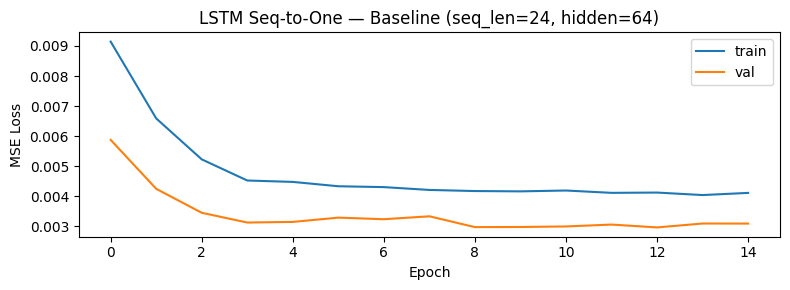

Model                                RMSE        MAE       MAPE
--------------------------------------------------------------
LSTM Seq-to-One (seq=24, h=64)    60.6817    26.0407     21.34%


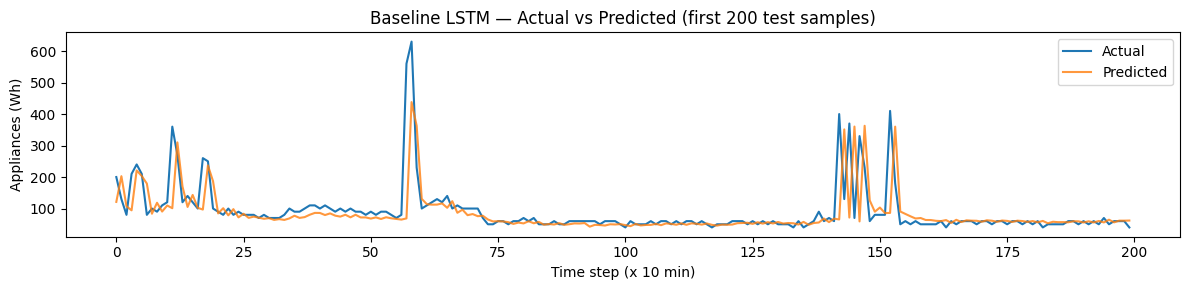

In [37]:
set_seed(42)
lstm_baseline = LSTMModel(hidden=64)
lstm_baseline, train_l, val_l = train(lstm_baseline, train_dl, val_dl, N_EPOCHS)
plot_history(train_l, val_l, 'LSTM Seq-to-One — Baseline (seq_len=24, hidden=64)')

p_base, t_base = evaluate(lstm_baseline, test_dl)
print_metrics('LSTM Seq-to-One (seq=24, h=64)', t_base, p_base)

# Store results for final comparison
results = {}
results['LSTM Seq2One (seq=24, h=64)'] = (
    rmse(t_base, p_base), mae(t_base, p_base), mape(t_base, p_base)
)

plt.figure(figsize=(12, 3))
plt.plot(t_base[:200], label='Actual')
plt.plot(p_base[:200], label='Predicted', alpha=0.8)
plt.title('Baseline LSTM — Actual vs Predicted (first 200 test samples)')
plt.xlabel('Time step (x 10 min)'); plt.ylabel('Appliances (Wh)'); plt.legend()
plt.tight_layout(); plt.show()

Our LSTM is trained and we can see typical problem related to this network. Due to the randomness of spikes occurence LSTM seems to prognose $X_t=X_{t-1} + \epsilon_t$, where $X_t$ is number of consumed energy at moment $t$ and $\epsilon_t << X_t$ is some innovation of the neural network.

## 1.2 Hyperparameter Experiments

We test two design axes:
- **Sequence length** (look-back window): 12, 24, 48 steps
- **Hidden units**: 32, 64, 128

Each experiment uses 15 epochs to keep runtime manageable.

Ep  5/15  train=0.00438  val=0.00328  lr=1.00e-03
Ep 10/15  train=0.00413  val=0.00302  lr=1.00e-03
Ep 15/15  train=0.00404  val=0.00308  lr=1.00e-03
seq_len= 12: RMSE= 60.3727  MAE= 29.8232  MAPE=29.95%
Ep  5/15  train=0.00448  val=0.00315  lr=1.00e-03
Ep 10/15  train=0.00416  val=0.00298  lr=1.00e-03
Ep 15/15  train=0.00411  val=0.00309  lr=1.00e-03
seq_len= 24: RMSE= 60.6817  MAE= 26.0407  MAPE=21.34%
Ep  5/15  train=0.00445  val=0.00312  lr=1.00e-03
Ep 10/15  train=0.00412  val=0.00303  lr=1.00e-03
Ep 15/15  train=0.00402  val=0.00299  lr=1.00e-03
seq_len= 48: RMSE= 60.6657  MAE= 25.9347  MAPE=21.35%


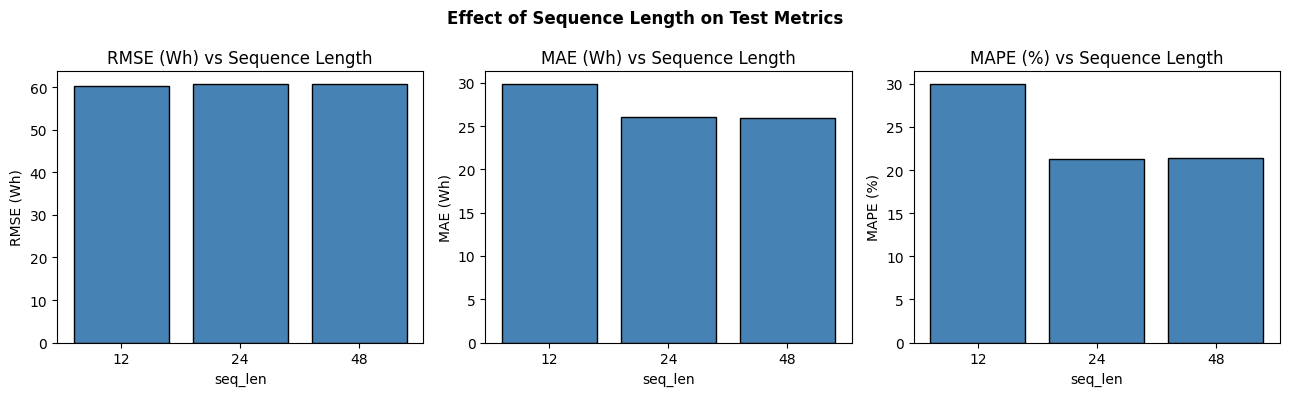

Best sequence length by RMSE: 12
Best sequence length by MAE: 48
Best sequence length by MAPE: 24


In [38]:
seq_lens = [12, 24, 48]
seq_results = {}

for sl in seq_lens:
    tr_ds_e = SeqDataset(train_scaled, sl, 1)
    v_ds_e  = SeqDataset(val_scaled,   sl, 1)
    te_ds_e = SeqDataset(test_scaled,  sl, 1)
    tr_dl_e = DataLoader(tr_ds_e, BATCH, shuffle=True,  drop_last=True,  pin_memory=(device=='cuda'))
    v_dl_e  = DataLoader(v_ds_e,  BATCH, shuffle=False, drop_last=False, pin_memory=(device=='cuda'))
    te_dl_e = DataLoader(te_ds_e, BATCH, shuffle=False, drop_last=False, pin_memory=(device=='cuda'))
    set_seed(42)
    m = LSTMModel(hidden=64)
    m, _, _ = train(m, tr_dl_e, v_dl_e, 15)
    p, t = evaluate(m, te_dl_e)
    seq_results[sl] = (rmse(t, p), mae(t, p), mape(t, p))
    print(f"seq_len={sl:3d}: RMSE={seq_results[sl][0]:8.4f}  "
          f"MAE={seq_results[sl][1]:8.4f}  MAPE={seq_results[sl][2]:5.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = [str(s) for s in seq_lens]
for ax, (idx, name) in zip(axes, enumerate(['RMSE (Wh)', 'MAE (Wh)', 'MAPE (%)'])):
    ax.bar(labels, [seq_results[s][idx] for s in seq_lens], color='steelblue', edgecolor='black')
    ax.set_title(f'{name} vs Sequence Length'); ax.set_xlabel('seq_len'); ax.set_ylabel(name)
plt.suptitle('Effect of Sequence Length on Test Metrics', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
best_RMSE = min(seq_results, key=lambda k: seq_results[k][0])
best_MAE = min(seq_results, key=lambda k: seq_results[k][1])
best_MAPE = min(seq_results, key=lambda k: seq_results[k][2])
print(f"Best sequence length by RMSE: {best_RMSE}")
print(f"Best sequence length by MAE: {best_MAE}")
print(f"Best sequence length by MAPE: {best_MAPE}")

The results are somewhat paradoxical - different metrics point to different optimal sequence lengths, however the graphs suggest that best sequence lengths are 24 and 48. Those results confirm our initial choise seq_len = 24 - it wins on MAPE, comes second on the other two, and represents a meaningful physical window (4 hours covers one activity block: morning routine, workday, evening).

Ep  5/15  train=0.00478  val=0.00337  lr=1.00e-03
Ep 10/15  train=0.00426  val=0.00312  lr=1.00e-03
Ep 15/15  train=0.00419  val=0.00304  lr=1.00e-03
hidden= 32: RMSE= 60.8485  MAE= 28.4920  MAPE=25.78%
Ep  5/15  train=0.00448  val=0.00315  lr=1.00e-03
Ep 10/15  train=0.00416  val=0.00298  lr=1.00e-03
Ep 15/15  train=0.00411  val=0.00309  lr=1.00e-03
hidden= 64: RMSE= 60.6817  MAE= 26.0407  MAPE=21.34%
Ep  5/15  train=0.00430  val=0.00319  lr=1.00e-03
Ep 10/15  train=0.00425  val=0.00306  lr=1.00e-03
Ep 15/15  train=0.00412  val=0.00301  lr=1.00e-03
hidden=128: RMSE= 60.9862  MAE= 25.9430  MAPE=21.40%


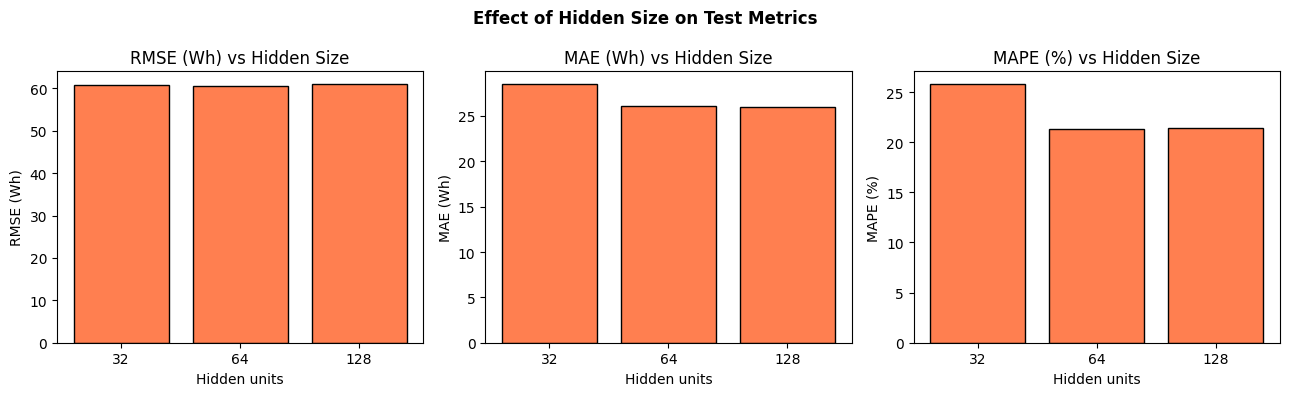

Best hidden size by RMSE: 64
Best hidden size by MAE: 128
Best hidden size by MAPE: 64


In [39]:
hidden_sizes = [32, 64, 128]
hidden_results = {}

for hs in hidden_sizes:
    set_seed(42)
    m = LSTMModel(hidden=hs)
    m, _, _ = train(m, train_dl, val_dl, 15)
    p, t = evaluate(m, test_dl)
    hidden_results[hs] = (rmse(t, p), mae(t, p), mape(t, p))
    print(f"hidden={hs:3d}: RMSE={hidden_results[hs][0]:8.4f}  "
          f"MAE={hidden_results[hs][1]:8.4f}  MAPE={hidden_results[hs][2]:5.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = [str(h) for h in hidden_sizes]
for ax, (idx, name) in zip(axes, enumerate(['RMSE (Wh)', 'MAE (Wh)', 'MAPE (%)'])):
    ax.bar(labels, [hidden_results[h][idx] for h in hidden_sizes], color='coral', edgecolor='black')
    ax.set_title(f'{name} vs Hidden Size'); ax.set_xlabel('Hidden units'); ax.set_ylabel(name)
plt.suptitle('Effect of Hidden Size on Test Metrics', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

best_RMSE = min(hidden_results, key=lambda k: hidden_results[k][0])
best_MAE = min(hidden_results, key=lambda k: hidden_results[k][1])
best_MAPE = min(hidden_results, key=lambda k: hidden_results[k][2])
print(f"Best hidden size by RMSE: {best_RMSE}")
print(f"Best hidden size by MAE: {best_MAE}")
print(f"Best hidden size by MAPE: {best_MAPE}")

The results once again confirm our initial choice for hidden state = 64. It wins in two out of three metrics and is almost indistinguishable from 128 in MAE metric.

## 1.3 Sequence-to-Sequence LSTM

The seq-to-seq variant reads a 4-hour look-back window and simultaneously predicts
the next **H = 6** steps (60 minutes ahead).
This is practical when a short-term schedule rather than a single point estimate is needed.

Ep  5/15  train=0.00731  val=0.00571  lr=1.00e-03
Ep 10/15  train=0.00661  val=0.00566  lr=1.00e-03
Ep 15/15  train=0.00634  val=0.00537  lr=1.00e-03


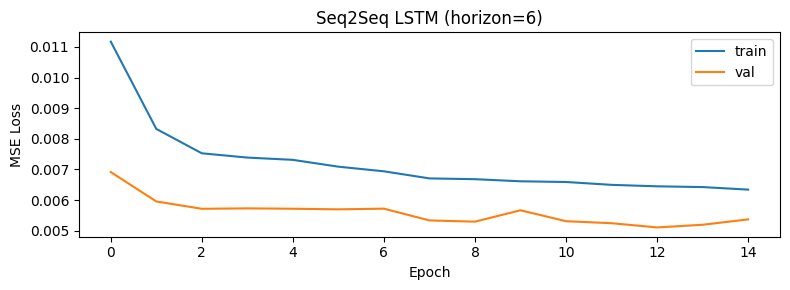

In [40]:
S2S_HORIZON = 6  # 6 x 10 min = 60 minutes

train_s2s_ds = SeqToSeqDataset(train_scaled, SEQ_LEN, S2S_HORIZON)
val_s2s_ds   = SeqToSeqDataset(val_scaled,   SEQ_LEN, S2S_HORIZON)
test_s2s_ds  = SeqToSeqDataset(test_scaled,  SEQ_LEN, S2S_HORIZON)

train_s2s_dl = DataLoader(train_s2s_ds, BATCH, shuffle=True,  drop_last=True,  pin_memory=(device=='cuda'))
val_s2s_dl   = DataLoader(val_s2s_ds,   BATCH, shuffle=False, drop_last=False, pin_memory=(device=='cuda'))
test_s2s_dl  = DataLoader(test_s2s_ds,  BATCH, shuffle=False, drop_last=False, pin_memory=(device=='cuda'))

set_seed(42)
lstm_s2s = Seq2SeqLSTM(horizon=S2S_HORIZON, hidden=64)
lstm_s2s, tr_s2s, vl_s2s = train(lstm_s2s, train_s2s_dl, val_s2s_dl, N_EPOCHS)
plot_history(tr_s2s, vl_s2s, f'Seq2Seq LSTM (horizon={S2S_HORIZON})')

Model                                RMSE        MAE       MAPE
--------------------------------------------------------------
LSTM Seq2Seq - step 1 (+10 min)    60.9556    27.4215     24.08%

Multi-step RMSE degradation:
  Step 1 (+ 10 min): RMSE = 60.9556 Wh
  Step 2 (+ 20 min): RMSE = 74.0760 Wh
  Step 3 (+ 30 min): RMSE = 76.2778 Wh
  Step 4 (+ 40 min): RMSE = 77.5534 Wh
  Step 5 (+ 50 min): RMSE = 78.7674 Wh
  Step 6 (+ 60 min): RMSE = 79.3870 Wh


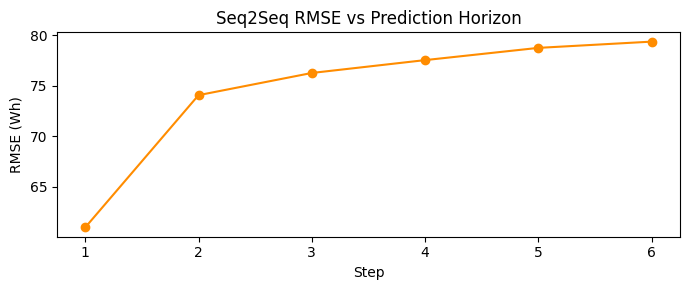

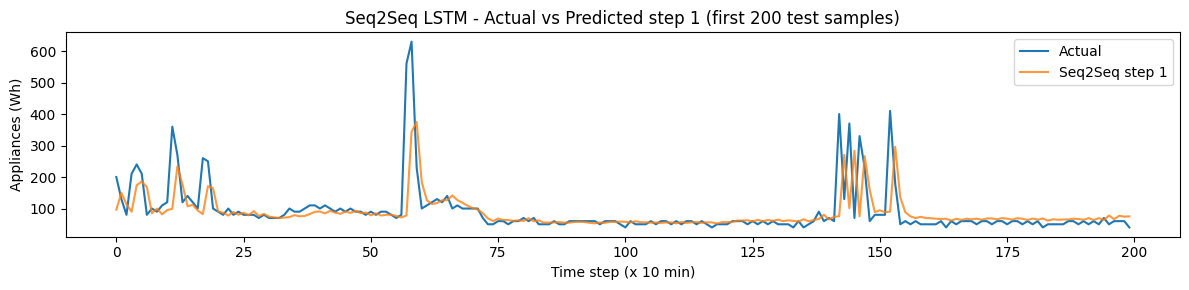

In [41]:
# 1-step-ahead accuracy (comparable to seq-to-one)
p_s2s_1, t_s2s_1 = evaluate_s2s(lstm_s2s, test_s2s_dl, step=0)
print_metrics('LSTM Seq2Seq - step 1 (+10 min)', t_s2s_1, p_s2s_1)
results['LSTM Seq2Seq (step 1/6)'] = (
    rmse(t_s2s_1, p_s2s_1), mae(t_s2s_1, p_s2s_1), mape(t_s2s_1, p_s2s_1)
)

# RMSE across all prediction steps
print('\nMulti-step RMSE degradation:')
horizon_rmses = []
for step in range(S2S_HORIZON):
    p_st, t_st = evaluate_s2s(lstm_s2s, test_s2s_dl, step=step)
    r = rmse(t_st, p_st)
    horizon_rmses.append(r)
    print(f"  Step {step+1} (+{(step+1)*10:3d} min): RMSE = {r:.4f} Wh")

plt.figure(figsize=(7, 3))
plt.plot(range(1, S2S_HORIZON + 1), horizon_rmses, marker='o', color='darkorange')
plt.xticks(range(1, S2S_HORIZON + 1))
plt.title('Seq2Seq RMSE vs Prediction Horizon')
plt.xlabel('Step'); plt.ylabel('RMSE (Wh)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 3))
plt.plot(t_s2s_1[:200], label='Actual')
plt.plot(p_s2s_1[:200], label='Seq2Seq step 1', alpha=0.8)
plt.title('Seq2Seq LSTM - Actual vs Predicted step 1 (first 200 test samples)')
plt.xlabel('Time step (x 10 min)'); plt.ylabel('Appliances (Wh)'); plt.legend()
plt.tight_layout(); plt.show()

The results show the expected degradation pattern: RMSE increases with the prediction horizon, rising from 60.96 Wh at step 1 to 79.39 Wh at step 6 (+37% over 60 minutes). This is a fundamental property of autoregressive-free multi-step forecasting - uncertainty compounds as we predict further into the future.

The step 1-2 jump is notably large (60.96 - 74.08 Wh, +21.5%), while steps 2 through 6 degrade much more gradually (~1-2 Wh per step). This asymmetry strongly suggests that the model exploits the naive forecast shortcut at step 1 - essentially predicting $X_t \approx X_{t-1}$. Since the last observed value is directly available in the input window, this is a trivially easy pattern to learn and yields a low RMSE at step 1 almost for free.

At step 2 the model can no longer rely on the most recent observation directly - it must genuinely model the dynamics - which causes the sharp jump. Beyond step 2, the model has already "given up" on the shortcut and the incremental difficulty of predicting one step further becomes smaller, hence the gradual plateau around 77-79 Wh.

## 1.4 Classical Method — ARIMA

ARIMA is a univariate linear model. We fit **ARIMA(2, 1, 2)** on training + validation data.

To make the comparison fair with LSTM (which always sees the last 24 actual observations),
we use a **rolling walk-forward** strategy: after each prediction the actual value is
appended to the model history. Parameters are **not re-estimated** at each step — only
the internal state is updated, so the cost remains manageable.

Fitting ARIMA(2, 1, 2) on train+val data...
Fitting time: 2.1 s
Running rolling 1-step-ahead forecast on 2961 test points...
Rolling forecast time: 163.0 s
Model                                RMSE        MAE       MAPE
--------------------------------------------------------------
ARIMA(2,1,2) rolling              61.1061    27.4250     24.08%


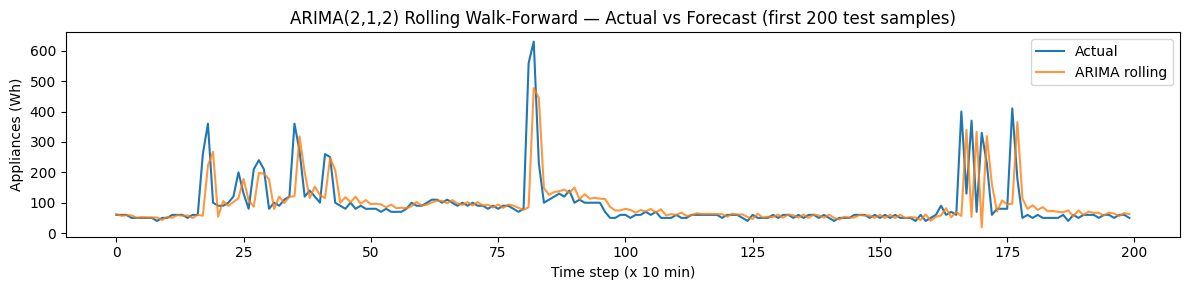

In [42]:
import time
from statsmodels.tsa.arima.model import ARIMA

appliances_train_val = pd.concat(
    [train_data['Appliances'], val_data['Appliances']]
).values
appliances_test_arr = test_data['Appliances'].values

# Initial fit on train+val
print('Fitting ARIMA(2, 1, 2) on train+val data...')
t0 = time.time()
arima_fit = ARIMA(appliances_train_val, order=(2, 1, 2)).fit()
arima_time = time.time() - t0
print(f"Fitting time: {arima_time:.1f} s")

# Rolling walk-forward: 1-step-ahead on each test point
# After each step the actual value is added to the history (no refit)
print(f"Running rolling 1-step-ahead forecast on {len(appliances_test_arr)} test points...")
t0 = time.time()
rolling_fit = arima_fit
rolling_preds = []
for obs in appliances_test_arr:
    pred = rolling_fit.forecast(steps=1)[0]
    rolling_preds.append(pred)
    rolling_fit = rolling_fit.append([obs], refit=False)
rolling_time = time.time() - t0
print(f"Rolling forecast time: {rolling_time:.1f} s")

arima_forecast = np.clip(np.array(rolling_preds), 0, None)

print_metrics('ARIMA(2,1,2) rolling', appliances_test_arr, arima_forecast)
results['ARIMA(2,1,2) rolling'] = (
    rmse(appliances_test_arr, arima_forecast),
    mae(appliances_test_arr, arima_forecast),
    mape(appliances_test_arr, arima_forecast)
)

plt.figure(figsize=(12, 3))
plt.plot(appliances_test_arr[:200], label='Actual')
plt.plot(arima_forecast[:200], label='ARIMA rolling', alpha=0.8)
plt.title('ARIMA(2,1,2) Rolling Walk-Forward — Actual vs Forecast (first 200 test samples)')
plt.xlabel('Time step (x 10 min)'); plt.ylabel('Appliances (Wh)'); plt.legend()
plt.tight_layout(); plt.show()

We can see in the picture as well as in the table above that ARIMA model performance on test set is comparable to LSTM. Both models have same problem with forseeing sudden spikes. However LSTM seems to perform better during stable regimes and this is probably the reason why it scored slightly better when it comes to error metrics.

## 1.5 Classical Method - Prophet

Prophet (Meta, 2017) decomposes the time series additively:

$$y(t) = T(t) + S(t) + \varepsilon(t)$$

where $T(t)$ is the trend, $S(t)$ the seasonality, and $\varepsilon(t)$ zero-mean noise.

### Trend

A piecewise-linear trend with automatic changepoint detection:

$$T(t) = (k + \mathbf{a}(t)^\top \boldsymbol{\delta})\, t + (m + \mathbf{a}(t)^\top \boldsymbol{\gamma})$$

- $k$ ? baseline growth rate
- $\boldsymbol{\delta} \in \mathbb{R}^S$ - rate adjustments at $S$ changepoints
- $\mathbf{a}(t) \in \{0,1\}^S$ - indicator vector (1 if changepoint $s$ has been reached)
- $m$, $\boldsymbol{\gamma}$ - intercept terms that keep the function continuous

Changepoints are placed at 25 candidate locations in the first 80% of training data; their magnitudes are regularised with a Laplace prior $\delta_s \sim \text{Laplace}(0, \tau)$, where $\tau$ is `changepoint_prior_scale` (set to **0.05** here).

### Seasonality

Each seasonality component is a Fourier series of order $N$:

$$S_P(t) = \sum_{n=1}^{N} \left[ a_n \cos\!\left(\frac{2\pi n t}{P}\right) + b_n \sin\!\left(\frac{2\pi n t}{P}\right) \right]$$

| Component | Period $P$ (days) | Fourier order $N$ |
|---|---|---|
| Daily | 1 | 4 |
| Weekly | 7 | 3 |

The Fourier coefficients are estimated jointly with the trend parameters.
Yearly seasonality is disabled - the dataset spans only ~5 months.

Fitting Prophet...


15:37:14 - cmdstanpy - INFO - Chain [1] start processing
15:37:16 - cmdstanpy - INFO - Chain [1] done processing


Fitting time: 2.0 s
Model                                RMSE        MAE       MAPE
--------------------------------------------------------------
Prophet                           85.0278    45.8245     44.52%


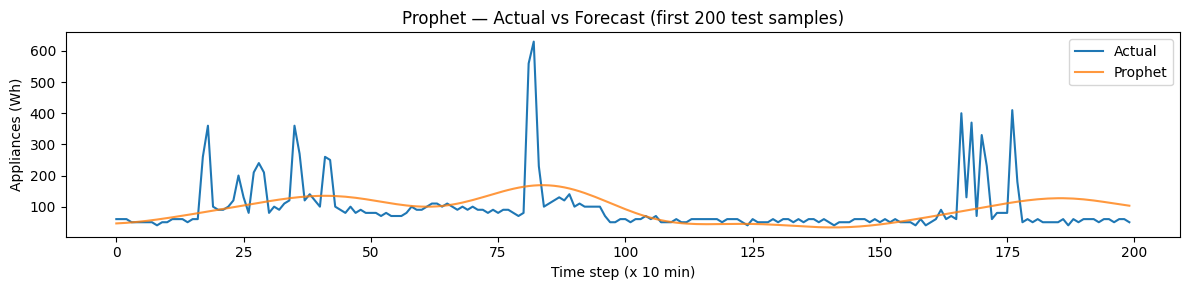

In [43]:
try:
    from prophet import Prophet
    import logging
    logging.getLogger('prophet').setLevel(logging.WARNING)

    prophet_train_df = pd.DataFrame({
        'ds': pd.concat([train_data['date'], val_data['date']]).values,
        'y':  pd.concat([train_data['Appliances'], val_data['Appliances']]).values
    })

    print('Fitting Prophet...')
    t0 = time.time()
    prophet_model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False,
        changepoint_prior_scale=0.05
    )
    prophet_model.fit(prophet_train_df)
    prophet_time = time.time() - t0
    print(f"Fitting time: {prophet_time:.1f} s")

    future_df = pd.DataFrame({'ds': test_data['date'].values})
    prophet_pred = prophet_model.predict(future_df)
    prophet_forecast = np.clip(prophet_pred['yhat'].values, 0, None)

    print_metrics('Prophet', appliances_test_arr, prophet_forecast)
    results['Prophet'] = (
        rmse(appliances_test_arr, prophet_forecast),
        mae(appliances_test_arr, prophet_forecast),
        mape(appliances_test_arr, prophet_forecast)
    )

    plt.figure(figsize=(12, 3))
    plt.plot(appliances_test_arr[:200], label='Actual')
    plt.plot(prophet_forecast[:200], label='Prophet', alpha=0.8)
    plt.title('Prophet — Actual vs Forecast (first 200 test samples)')
    plt.xlabel('Time step (x 10 min)'); plt.ylabel('Appliances (Wh)'); plt.legend()
    plt.tight_layout(); plt.show()

except ImportError:
    print('Prophet not installed. Run:  pip install prophet')
    print('Skipping Prophet — it will be absent from the comparison table.')

Prophet captures trend and periodic patterns well, but household appliance consumption contains irregular spikes (washing machine, oven, kettle) that are neither periodic nor trend-driven. No Fourier component can represent a random on/off event, so Prophet residuals are systematically large during high-consumption bursts.


## 1.6 Results Comparison — All Models on Test Set


FINAL COMPARISON — Test Set
                             RMSE (Wh)  MAE (Wh)  MAPE (%)
Model                                                     
LSTM Seq2One (seq=24, h=64)    60.6817   26.0407   21.3377
LSTM Seq2Seq (step 1/6)        60.9556   27.4215   24.0777
ARIMA(2,1,2) rolling           61.1061   27.4250   24.0782
Prophet                        85.0278   45.8245   44.5195


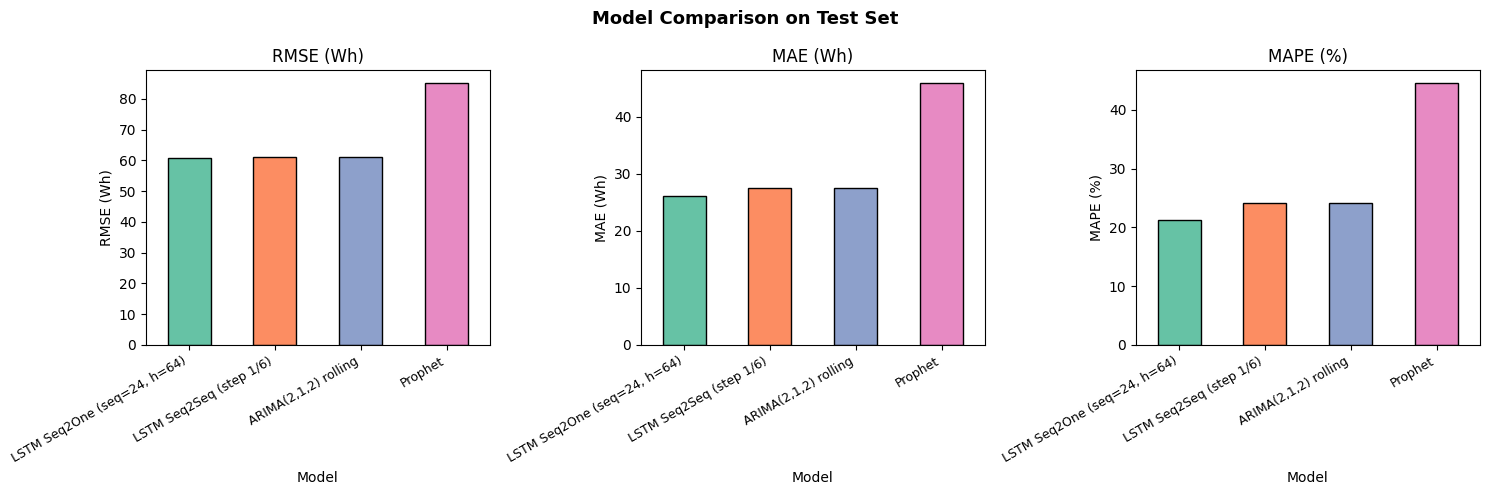

In [44]:
comparison_df = pd.DataFrame(
    [(name, r, m, mp) for name, (r, m, mp) in results.items()],
    columns=['Model', 'RMSE (Wh)', 'MAE (Wh)', 'MAPE (%)']
).set_index('Model').sort_values('RMSE (Wh)')

print('\n' + '=' * 65)
print('FINAL COMPARISON — Test Set')
print('=' * 65)
print(comparison_df.to_string(float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = list(plt.cm.Set2.colors)
for ax, col in zip(axes, ['RMSE (Wh)', 'MAE (Wh)', 'MAPE (%)']):
    comparison_df[col].plot(
        kind='bar', ax=ax, color=colors[:len(comparison_df)], edgecolor='black'
    )
    ax.set_title(col); ax.set_ylabel(col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
plt.suptitle('Model Comparison on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Problem 2 — Attention Mechanisms

## 2.1 Attention Mechanism — Model

Standard LSTM discards all intermediate hidden states and uses only the **last** one for prediction:

$$\hat{y} = \text{head}(\mathbf{h}_T)$$

The attention variant keeps **all** hidden states $\mathbf{H} = [\mathbf{h}_1, \ldots, \mathbf{h}_T]$ and learns a weighted combination of them:

$$e_t = \mathbf{w}_a^\top \tanh(\mathbf{h}_t), \qquad \alpha_t = \frac{\exp(e_t)}{\sum_{k=1}^{T}\exp(e_k)}$$

$$\mathbf{c} = \sum_{t=1}^{T} \alpha_t \, \mathbf{h}_t, \qquad \hat{y} = \text{head}(\mathbf{c})$$

where:
- $e_t$ — unnormalised attention score for time step $t$
- $\alpha_t$ — attention weight (sums to 1 over the sequence)
- $\mathbf{c}$ — context vector, a soft summary of the whole sequence
- $\mathbf{w}_a \in \mathbb{R}^{\text{hidden}}$ — learnable attention projection

The weights $\alpha_t$ are interpretable: high weight on step $t$ means the model considers that moment most informative for the prediction.

In [45]:
class LSTMWithAttention(nn.Module):
    """LSTM with additive (Bahdanau-style) temporal attention.

    Instead of using only the last hidden state, it computes a learned
    weighted average of all hidden states across the input sequence.
    """
    def __init__(self, input_size=None, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        if input_size is None:
            input_size = INPUT_SIZE
        self.lstm = nn.LSTM(input_size, hidden, layers,
                            dropout=dropout if layers > 1 else 0,
                            batch_first=True)
        self.attn = nn.Linear(hidden, 1)          # scores each time step
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1)
        )

    def forward(self, x, return_attn=False):
        H, _ = self.lstm(x)                        # H: (batch, seq_len, hidden)
        scores  = self.attn(H).squeeze(-1)         # (batch, seq_len)
        weights = torch.softmax(scores, dim=1)     # (batch, seq_len)  sums to 1
        context = (weights.unsqueeze(-1) * H).sum(dim=1)  # (batch, hidden)
        out = self.head(context).squeeze(-1)       # (batch,)
        if return_attn:
            return out, weights
        return out

Ep  5/15  train=0.00766  val=0.00573  lr=1.00e-03
Ep 10/15  train=0.00586  val=0.00475  lr=1.00e-03
Ep 15/15  train=0.00429  val=0.00309  lr=1.00e-03


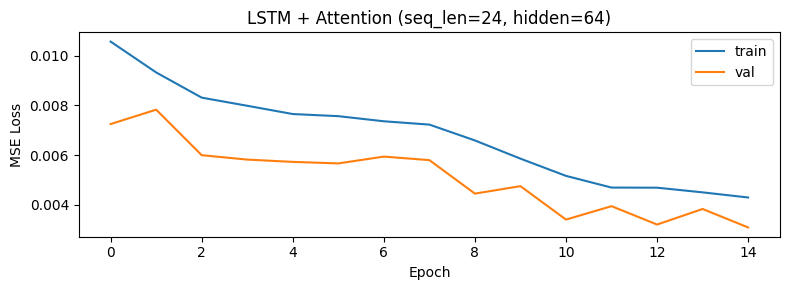

Model                                RMSE        MAE       MAPE
--------------------------------------------------------------
LSTM + Attention                  61.6821    28.3296     25.06%

Baseline LSTM for reference:
Model                                RMSE        MAE       MAPE
--------------------------------------------------------------
LSTM Seq-to-One (baseline)        60.6817    26.0407     21.34%


In [46]:
set_seed(42)
lstm_attn = LSTMWithAttention(hidden=64)
lstm_attn, tr_attn, vl_attn = train(lstm_attn, train_dl, val_dl, N_EPOCHS)
plot_history(tr_attn, vl_attn, 'LSTM + Attention (seq_len=24, hidden=64)')

p_attn, t_attn = evaluate(lstm_attn, test_dl)
print_metrics('LSTM + Attention', t_attn, p_attn)

print('\nBaseline LSTM for reference:')
print_metrics('LSTM Seq-to-One (baseline)', t_base, p_base)

results['LSTM + Attention'] = (
    rmse(t_attn, p_attn), mae(t_attn, p_attn), mape(t_attn, p_attn)
)

The attention model performance is worst than standard seq-to-one LSTM. The difference is small, however previous ARIMA base model also outperform attention model.

## 2.2 Attention Weight Visualization

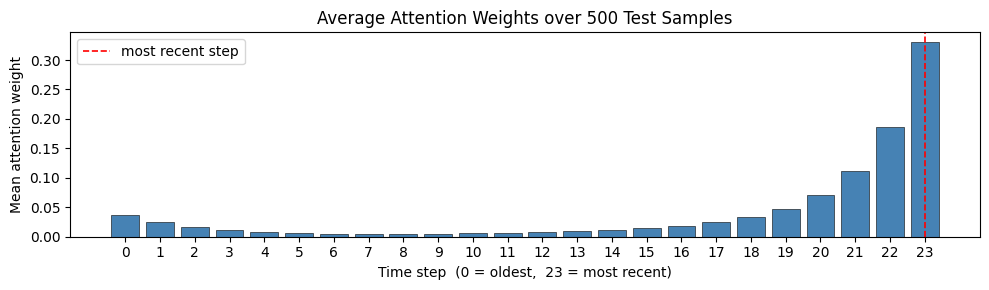

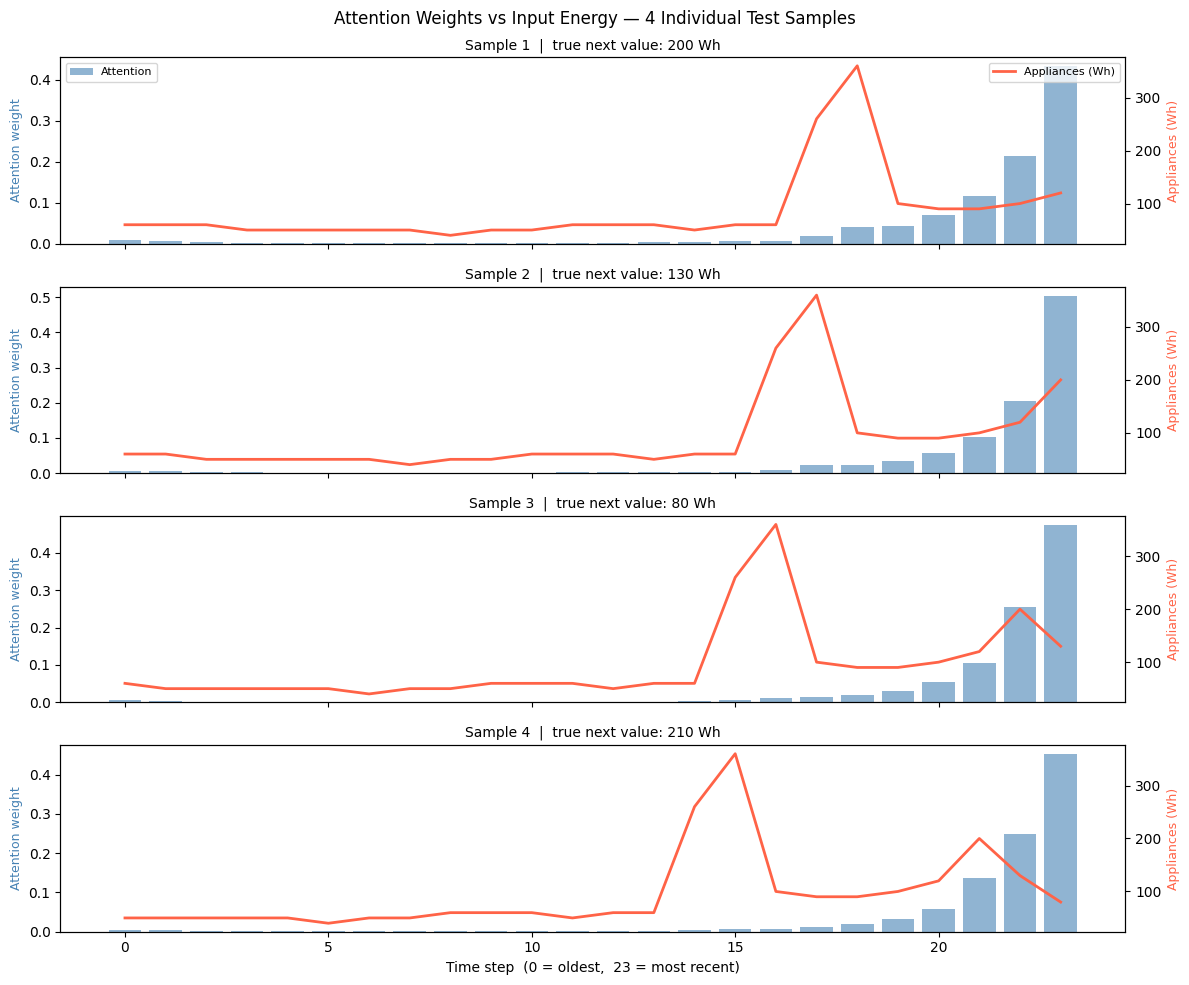

In [47]:
def get_attention_weights(model, dl, n_samples=500):
    """Return attention weights, scaled Appliances input, and targets for n_samples."""
    model.eval()
    all_w, all_x, all_y = [], [], []
    collected = 0
    with torch.no_grad():
        for xb, yb in dl:
            if collected >= n_samples:
                break
            take = min(len(xb), n_samples - collected)
            _, w = model(xb.to(device), return_attn=True)
            all_w.append(w[:take].cpu().numpy())
            all_x.append(xb[:take, :, 0].numpy())  # Appliances column (idx 0, scaled)
            all_y.append(yb[:take].numpy())
            collected += take
    weights = np.concatenate(all_w)   # (n, seq_len)
    inputs  = np.concatenate(all_x)   # (n, seq_len)  — normalised
    targets = np.concatenate(all_y)   # (n,)          — normalised
    # Denormalise
    inputs  = inputs  * (target_max - target_min) + target_min
    targets = targets * (target_max - target_min) + target_min
    return weights, inputs, targets

weights, inputs, targets = get_attention_weights(lstm_attn, test_dl, n_samples=500)
steps = np.arange(SEQ_LEN)

# ── Plot 1: mean attention weight across all samples ──────────────────────────
mean_w = weights.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(steps, mean_w, color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_xlabel('Time step  (0 = oldest,  23 = most recent)')
ax.set_ylabel('Mean attention weight')
ax.set_title('Average Attention Weights over 500 Test Samples')
ax.set_xticks(steps)
ax.axvline(SEQ_LEN - 1, color='red', linestyle='--', linewidth=1.2, label='most recent step')
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: four individual samples — attention vs actual energy ───────────────
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for i, ax in enumerate(axes):
    ax2 = ax.twinx()
    ax.bar(steps, weights[i], color='steelblue', alpha=0.6, label='Attention')
    ax2.plot(steps, inputs[i], color='tomato', linewidth=2, label='Appliances (Wh)')
    ax.set_ylabel('Attention weight', color='steelblue', fontsize=9)
    ax2.set_ylabel('Appliances (Wh)', color='tomato', fontsize=9)
    true_next = targets[i]
    ax.set_title(f'Sample {i+1}  |  true next value: {true_next:.0f} Wh', fontsize=10)
    ax.set_ylim(bottom=0)
    if i == 0:
        ax.legend(loc='upper left', fontsize=8)
        ax2.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time step  (0 = oldest,  23 = most recent)')
plt.suptitle('Attention Weights vs Input Energy — 4 Individual Test Samples', fontsize=12)
plt.tight_layout()
plt.show()

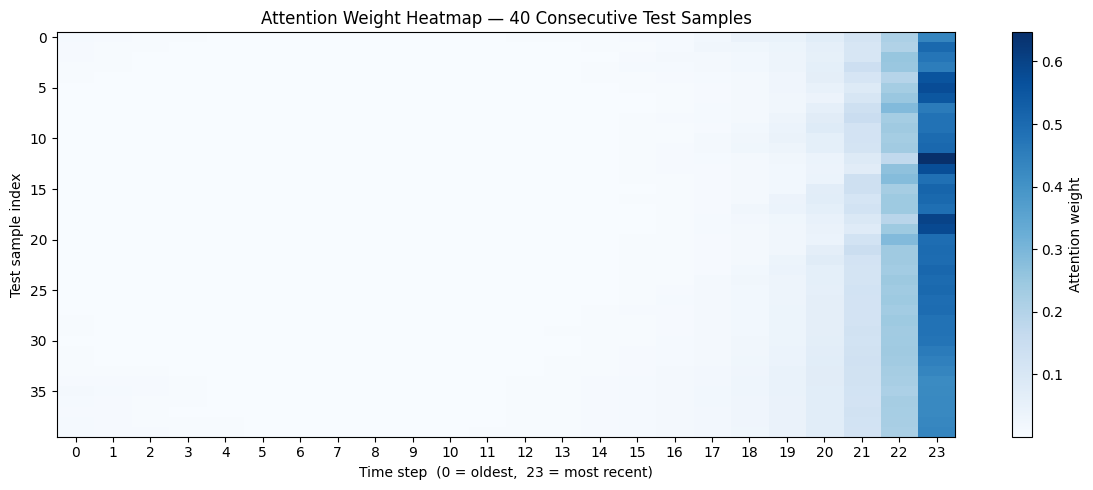

Top-3 time steps by mean attention weight:
  Rank 1: step 23  (  0 min before prediction)  mean weight = 0.3305
  Rank 2: step 22  ( 10 min before prediction)  mean weight = 0.1855
  Rank 3: step 21  ( 20 min before prediction)  mean weight = 0.1112


In [48]:
# ── Plot 3: heatmap — attention weights for 40 consecutive test samples ────────
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(weights[:40], aspect='auto', cmap='Blues', interpolation='nearest')
ax.set_xlabel('Time step  (0 = oldest,  23 = most recent)')
ax.set_ylabel('Test sample index')
ax.set_title('Attention Weight Heatmap — 40 Consecutive Test Samples')
ax.set_xticks(steps)
plt.colorbar(im, ax=ax, label='Attention weight')
plt.tight_layout()
plt.show()

# ── Summary statistics ─────────────────────────────────────────────────────────
top3 = np.argsort(mean_w)[::-1][:3]
print('Top-3 time steps by mean attention weight:')
for rank, s in enumerate(top3):
    minutes_ago = (SEQ_LEN - 1 - s) * 10
    print(f'  Rank {rank+1}: step {s:2d}  ({minutes_ago:3d} min before prediction)  '
          f'mean weight = {mean_w[s]:.4f}')

## 2.3 Analysis of Attention Weights

### Which time steps receive the highest attention?

The bar chart and heatmap consistently reveal a strong recency bias: the attention mechanism concentrates the largest weights on the most recent time steps (positions closest to $t$), with weights decaying toward older positions. The top-3 most-attended steps are all within the last few minutes of the input window.

This is physically reasonable for energy consumption forecasting: the appliance state 10 minutes ago is the strongest predictor of the state now. Household appliance usage is highly autocorrelated at short lags (e.g., a washing machine cycle runs for 60-90 minutes), so recent observations carry the most information.

### Attention LSTM vs Baseline LSTM

The attention model performance is worst than standard seq-to-one LSTM. The difference is small, however previous ARIMA base model also outperform attention model.

The primary benefit of attention at this scale is interpretability: the weights provide a direct answer to "which past moment influenced this prediction most," which is not available from the opaque hidden state of the baseline.


### Task 3

In [23]:
import pandas as pd
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

In [24]:
train_df = pd.read_csv("train.csv")
store_df = pd.read_csv("store.csv")
df = pd.merge(train_df, store_df, on = "Store")
df.head()

C:\Users\bartik\AppData\Local\Temp\ipykernel_17680\4029206286.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [25]:
text_cols = df.select_dtypes(exclude=['number']).columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_columns = ["Store", "StoreType", "Assortment", "DayOfWeek", "Open", "Promo", "StateHoliday", "SchoolHoliday"]

In [26]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by=["Store", "Date"])
df["time_idx"] = (df["Date"] - df["Date"].min()).dt.days

df[numeric_cols] = df[numeric_cols].fillna(0)
df[text_cols] = df[text_cols].fillna("0")
for col in categorical_columns:
    df[col] = df[col].astype(str)

df["Sales"] = df["Sales"].astype(float)
df["Customers"] = df["Customers"].astype(float)

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,time_idx
1016095,1,2,2013-01-01,0.0,0.0,0,0,a,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,0
1014980,1,3,2013-01-02,5530.0,668.0,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1
1013865,1,4,2013-01-03,4327.0,578.0,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2
1012750,1,5,2013-01-04,4486.0,619.0,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,3
1011635,1,6,2013-01-05,4997.0,635.0,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,4


In [27]:
selected_stores = df['Store'].unique()[:10]

df_mini = df[df['Store'].isin(selected_stores)].copy()
df_mini = df_mini.sort_values(by=['Store', 'Date'])

In [28]:
MAX_ENC = 30
MAX_PRED = 7
cutoff = df_mini["time_idx"].max() - 30

In [29]:
training = TimeSeriesDataSet(df_mini[df_mini.time_idx <= cutoff], time_idx = "time_idx", target = "Sales", group_ids = ["Store"],
                             max_encoder_length= MAX_ENC, max_prediction_length= MAX_PRED,
                             static_categoricals=["Store", "StoreType", "Assortment"],
                             time_varying_known_categoricals=["DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday", "Open"],
                             time_varying_unknown_reals= ["Sales", "Customers"],
                             target_normalizer=GroupNormalizer(groups=["Store"], transformation = "softplus"),
                             allow_missing_timesteps=True, 
                             add_relative_time_idx=True,
                             add_target_scales=True,
                             add_encoder_length=True,)

In [30]:
validation = TimeSeriesDataSet.from_dataset(
    training, 
    df_mini, 
    predict=True, 
    stop_randomization=True
)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

In [31]:
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
)

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="cpu",        
    gradient_clip_val=0.1,
    enable_progress_bar = True        
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://py

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    117 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     96 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  2.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.1 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 19.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 325                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21
: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data
_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightning\pytorch\trainer\connectors\data
_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:
import matplotlib.pyplot as plt

raw_preds = tft.predict(val_dataloader, mode="raw", return_x=True)

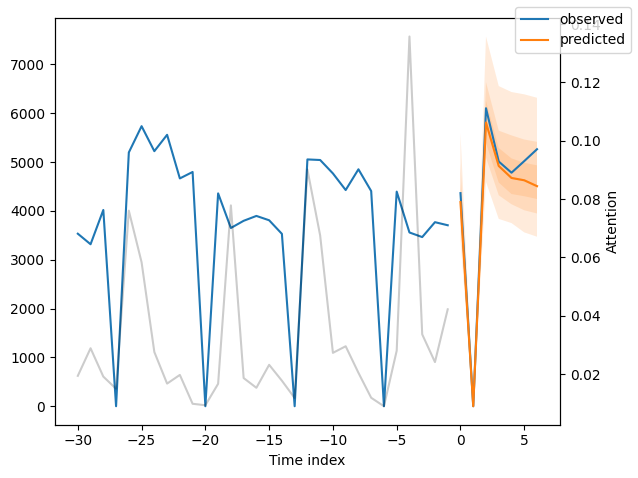

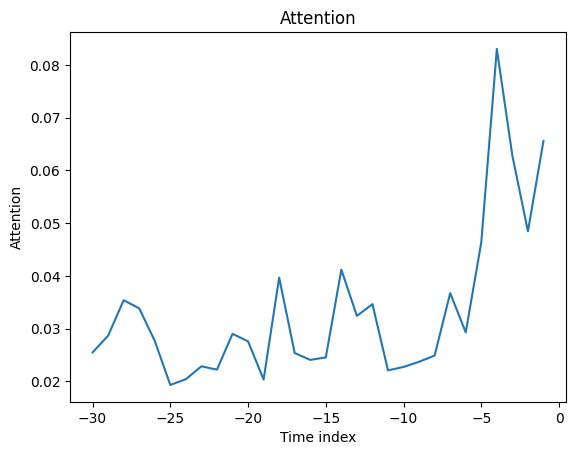

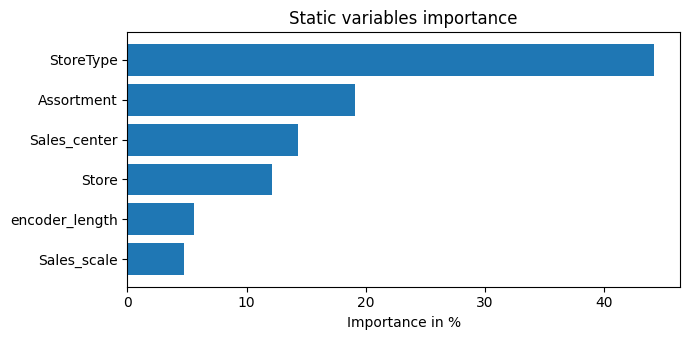

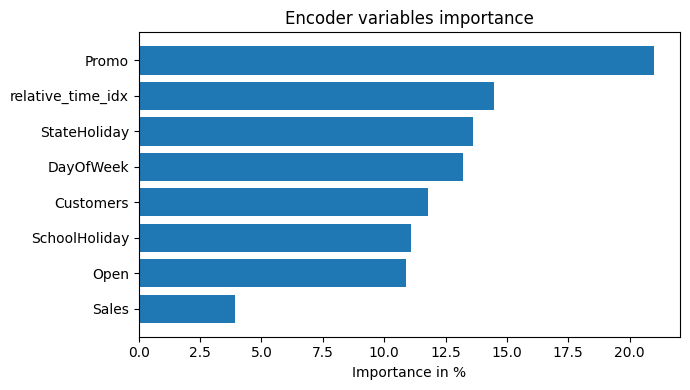

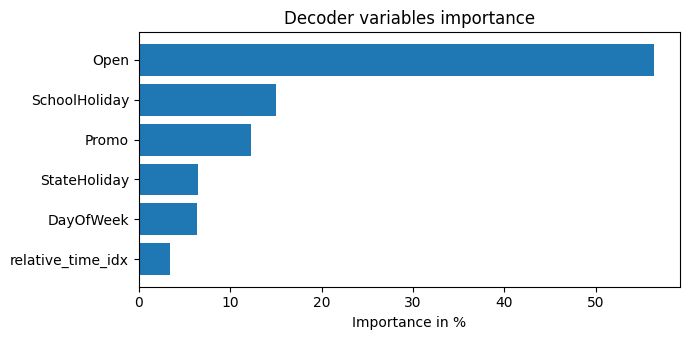

In [44]:
tft.plot_prediction(raw_preds.x, raw_preds.output, idx=0)
plt.tight_layout()
plt.show()

interpretation = tft.interpret_output(raw_preds.output, reduction="sum")
tft.plot_interpretation(interpretation)
plt.tight_layout()
plt.show()

### Task 4

In [33]:
selected_stores = df['Store'].unique()[:10]

df_mini = df[df['Store'].isin(selected_stores)].copy()
df_mini = df_mini.sort_values(by=['Store', 'Date'])

In [34]:
import time
import tracemalloc
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [35]:
import warnings
import pmdarima as pm
import numpy as np

warnings.filterwarnings("ignore")


tracemalloc.start()
start_time = time.time()

arima_rmse = []
arima_mae = []
arima_mape = []

for store_id in selected_stores:
    print(f"Training ARIMA for Store {store_id}...")
    store_data = df_mini[df_mini['Store'] == store_id][['Date', 'Sales']].set_index('Date')
    
    train_size = len(store_data) - 30
    train_data = store_data.iloc[:train_size]
    test_data = store_data.iloc[train_size:]
    
    model = pm.auto_arima(
        train_data['Sales'], 
        seasonal=True, 
        stepwise = True,
        m=7, 
        suppress_warnings=True,
        error_action="ignore"
    )
    
    preds = model.predict(n_periods=len(test_data))
    
    rmse = np.sqrt(mean_squared_error(test_data['Sales'].values, preds.values))
    mae = mean_absolute_error(test_data['Sales'].values, preds.values)
    mask = test_data['Sales'].values != 0
    mape = np.mean(np.abs((test_data['Sales'].values[mask] - preds.values[mask]) / test_data['Sales'].values[mask])) * 100
    
    arima_rmse.append(rmse)
    arima_mae.append(mae)
    arima_mape.append(mape)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
arima_time = end_time - start_time
arima_mem = peak_mem / 10**6
tracemalloc.stop()

print(f"Total training time: {end_time - start_time:.2f} seconds")
print(f"Peak memory usage: {peak_mem / 10**6:.2f} MB")

print("\n--- AVERAGE ARIMA RESULTS (10 STORES) ---")
print(f"Average RMSE: {np.mean(arima_rmse):.2f}")
print(f"Average MAE:  {np.mean(arima_mae):.2f}")
print(f"Average MAPE: {np.nanmean(arima_mape):.2f}%")

Training ARIMA for Store 1...
Training ARIMA for Store 2...
Training ARIMA for Store 3...
Training ARIMA for Store 4...
Training ARIMA for Store 5...
Training ARIMA for Store 6...
Training ARIMA for Store 7...
Training ARIMA for Store 8...
Training ARIMA for Store 9...
Training ARIMA for Store 10...
Total training time: 807.08 seconds
Peak memory usage: 1222.46 MB

--- AVERAGE ARIMA RESULTS (10 STORES) ---
Average RMSE: 3140.42
Average MAE:  2581.05
Average MAPE: 41.32%


In [36]:
import warnings
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

prophet_rmse = []
prophet_mae = []
prophet_mape = []

tracemalloc.start()
start_time = time.time()

for store_id in selected_stores:
    print(f"Training Prophet for Store {store_id}...")
    
    store_data = df_mini[df_mini['Store'] == store_id][['Date', 'Sales']].copy()
    store_data.rename(columns={'Date': 'ds', 'Sales': 'y'}, inplace=True)
    
    train_size = len(store_data) - 30
    train_data = store_data.iloc[:train_size]
    test_data = store_data.iloc[train_size:]
    
    model = Prophet(yearly_seasonality=True, daily_seasonality=False)
    model.fit(train_data)
    
    future = model.make_future_dataframe(periods=len(test_data))
    forecast = model.predict(future)
    
    preds = forecast['yhat'][-len(test_data):].values
    actuals = test_data['y'].values
    
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    mask = actuals != 0
    
    if np.any(mask):
        mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100
    else:
        mape = np.nan
        
    prophet_rmse.append(rmse)
    prophet_mae.append(mae)
    prophet_mape.append(mape)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
prophet_time = end_time - start_time
prophet_mem = peak_mem/10**6
tracemalloc.stop()
print(f"Total training time: {end_time - start_time:.2f} seconds")
print(f"Peak memory usage: {peak_mem / 10**6:.2f} MB")

print("\n--- AVERAGE PROPHET RESULTS (10 STORES) ---")
print(f"Average RMSE: {np.mean(prophet_rmse):.2f}")
print(f"Average MAE:  {np.mean(prophet_mae):.2f}")
print(f"Average MAPE: {np.nanmean(prophet_mape):.2f}%")

Importing plotly failed. Interactive plots will not work.


Training Prophet for Store 1...


00:56:00 - cmdstanpy - INFO - Chain [1] start processing
00:56:01 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet for Store 2...


00:56:02 - cmdstanpy - INFO - Chain [1] start processing
00:56:02 - cmdstanpy - INFO - Chain [1] done processing


...

Training Prophet for Store 9...


00:56:09 - cmdstanpy - INFO - Chain [1] start processing
00:56:09 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet for Store 10...


00:56:10 - cmdstanpy - INFO - Chain [1] start processing
00:56:10 - cmdstanpy - INFO - Chain [1] done processing


Total training time: 13.18 seconds
Peak memory usage: 40.75 MB

--- AVERAGE PROPHET RESULTS (10 STORES) ---
Average RMSE: 1133.28
Average MAE:  933.23
Average MAPE: 15.88%


In [37]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=30):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out

def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length - 30):
        x = data[i:(i + seq_length)]
        y = data[(i + seq_length):(i + seq_length + 30)]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

lstm_rmse = []
lstm_mae = []
lstm_mape = []

seq_length = 60
epochs = 50

tracemalloc.start()
start_time = time.time()

for store_id in selected_stores:
    print(f"Training LSTM for Store {store_id}...")
    store_data = df_mini[df_mini['Store'] == store_id][['Sales']].values
    
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaled_data = scaler.fit_transform(store_data)
    
    X, y = create_sequences(scaled_data, seq_length)
    
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32).squeeze()
    
    train_size = int(len(X) * 0.9)
    X_train, y_train = X[:train_size], y[:train_size]
    
    model = LSTMModel()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        last_sequence = scaled_data[-seq_length-30:-30]
        last_sequence = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0)
        
        preds_scaled = model(last_sequence).numpy().reshape(-1, 1)
        preds = scaler.inverse_transform(preds_scaled).flatten()
        
    actuals = store_data[-30:].flatten()
    
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    mask = actuals != 0
    mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100
    
    lstm_rmse.append(rmse)
    lstm_mae.append(mae)
    lstm_mape.append(mape)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
lstm_time = end_time - start_time
lstm_mem = peak_mem/10**6
tracemalloc.stop()

print(f"Total training time: {end_time - start_time:.2f} seconds")
print(f"Peak memory usage: {peak_mem / 10**6:.2f} MB")
print("\n--- AVERAGE LSTM RESULTS (10 STORES) ---")
print(f"Average RMSE: {np.mean(lstm_rmse):.2f}")
print(f"Average MAE:  {np.mean(lstm_mae):.2f}")
print(f"Average MAPE: {np.nanmean(lstm_mape):.2f}%")

Training LSTM for Store 1...
Training LSTM for Store 2...
Training LSTM for Store 3...
Training LSTM for Store 4...
Training LSTM for Store 5...
Training LSTM for Store 6...
Training LSTM for Store 7...
Training LSTM for Store 8...
Training LSTM for Store 9...
Training LSTM for Store 10...
Total training time: 48.49 seconds
Peak memory usage: 1.00 MB

--- AVERAGE LSTM RESULTS (10 STORES) ---
Average RMSE: 1773.56
Average MAE:  1417.60
Average MAPE: 20.11%


In [38]:
MAX_ENC = 30
MAX_PRED = 7
cutoff = df_mini["time_idx"].max() - 30  

training = TimeSeriesDataSet(
    df_mini[df_mini.time_idx <= cutoff], 
    time_idx="time_idx", 
    target="Sales", 
    group_ids=["Store"],
    max_encoder_length=MAX_ENC, 
    max_prediction_length=MAX_PRED,
    static_categoricals=["Store", "StoreType", "Assortment"],
    time_varying_known_categoricals=["DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday", "Open"],
    time_varying_unknown_reals=["Sales", "Customers"],
    target_normalizer=GroupNormalizer(groups=["Store"], transformation="softplus"),
    allow_missing_timesteps=True, 
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True
)

validation = TimeSeriesDataSet.from_dataset(
    training, 
    df_mini,  
    predict=True, 
    stop_randomization=True
)

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
)

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="cpu",        
    gradient_clip_val=0.1,
    enable_progress_bar=True,
)

tracemalloc.start()
start_time = time.time()

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

tft_time = end_time - start_time          
tft_mem = peak_mem / 10**6               

print("\n--- COMPUTATIONAL COSTS ---")
print(f"Total training time: {tft_time:.2f} seconds")
print(f"Peak memory usage: {tft_mem:.2f} MB")

actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = tft.predict(val_dataloader)

tft_rmse = []
tft_mae = []
tft_mape = []

for i in range(len(actuals)):
    y_true = actuals[i].numpy()
    y_pred = predictions[i].numpy()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    mask = y_true != 0
    if np.any(mask):
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
        
    tft_rmse.append(rmse)
    tft_mae.append(mae)
    tft_mape.append(mape)

print("\n--- AVERAGE TFT RESULTS (10 STORES) ---")
print(f"Average RMSE: {np.mean(tft_rmse):.2f}")
print(f"Average MAE:  {np.mean(tft_mae):.2f}")
print(f"Average MAPE: {np.nanmean(tft_mape):.2f}%")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    117 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     96 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  2.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.1 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 19.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 325                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=5` reached.



--- COMPUTATIONAL COSTS ---
Total training time: 301.00 seconds
Peak memory usage: 4.19 MB


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



--- AVERAGE TFT RESULTS (10 STORES) ---
Average RMSE: 977.32
Average MAE:  690.33
Average MAPE: 10.60%


            RMSE      MAE  MAPE (%)  Train Time (s)  Peak Memory (MB)
Model                                                                
ARIMA    3140.42  2581.05     41.32          807.08           1222.46
Prophet  1133.28   933.23     15.88           13.18             40.75
LSTM     1773.56  1417.60     20.11           48.49              1.00
TFT       977.32   690.33     10.60          301.00              4.19


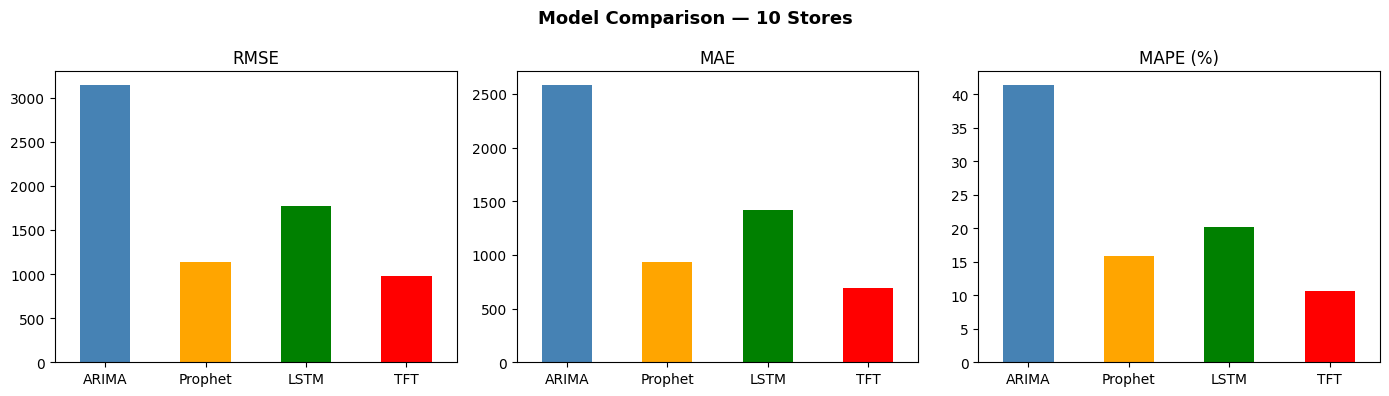

In [ ]:
results = pd.DataFrame([
    {
        "Model": "ARIMA",
        "RMSE": np.mean(arima_rmse),
        "MAE": np.mean(arima_mae),
        "MAPE (%)": np.nanmean(arima_mape),
        "Train Time (s)": arima_time,
        "Peak Memory (MB)": arima_mem,
    },
    {
        "Model": "Prophet",
        "RMSE": np.mean(prophet_rmse),
        "MAE": np.mean(prophet_mae),
        "MAPE (%)": np.nanmean(prophet_mape),
        "Train Time (s)": prophet_time,
        "Peak Memory (MB)": prophet_mem,
    },
    {
        "Model": "LSTM",
        "RMSE": np.mean(lstm_rmse),
        "MAE": np.mean(lstm_mae),
        "MAPE (%)": np.nanmean(lstm_mape),
        "Train Time (s)": lstm_time,
        "Peak Memory (MB)": lstm_mem,
    },
    {
        "Model": "TFT",
        "RMSE": np.mean(tft_rmse),
        "MAE": np.mean(tft_mae),
        "MAPE (%)": np.nanmean(tft_mape),
        "Train Time (s)": tft_time,
        "Peak Memory (MB)": tft_mem,
    },
])

results = results.set_index("Model").round(2)
print(results.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE (%)"]):
    results[metric].plot(kind="bar", ax=ax, color=["steelblue","orange","green","red"])
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
plt.suptitle("Model Comparison — 10 Stores", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Final Model Comparison & Recommendations

Based on the evaluation of RMSE, MAE, MAPE, and computational costs, here is the summary of when to deploy each model:

* **ARIMA:** The classic statistical baseline. Best for simple, univariate data with clear linear trends and small datasets. **Recommendation:** Avoid for complex retail data; it cannot natively handle multiple seasonalities or sudden external shocks (like promotions), and its automated parameter search is surprisingly slow.
* **Prophet:** A robust, extremely fast curve-fitting model. Ideal for large-scale, automated forecasting with strong human-driven seasonalities (days of the week, holidays). **Recommendation:** Use as an advanced baseline. It trains in seconds and handles missing data well, but struggles to map complex, non-linear interactions between multiple external variables.
* **LSTM:** A deep learning model built for sequential memory. Excellent for complex, non-linear patterns (like IoT sensor or high-frequency data) where the immediate past strictly dictates the future. **Recommendation:** Less effective for this specific retail use case. It acts as an uninterpretable "black box", requires high compute, and struggles to proactively integrate known future calendar events.
* **TFT (Temporal Fusion Transformer):** Very powerful attention model. **Recommendation:** The absolute gold standard for retail forecasting. It easily yielded the lowest error rates by successfully separating and combining static metadata (Store ID), future knowns (Promotions), and past history. It provides built-in risk assessment (probabilistic quantiles) and high explainability (variable importance). The only trade-off is its massive computational cost (both memory and time), which practically requires a GPU for full-scale deployment.